In [1]:
!pip install networkx

You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [12]:
!pip install seaborn

     |████████████████████████████████| 293 kB 928 kB/s eta 0:00:01
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [9]:
import networkx as nx

import os
import numpy as np
import matplotlib.pyplot as plt
import gc

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from spektral.data import Dataset, Graph
from spektral.layers import GCNConv
from spektral.transforms import LayerPreprocess, NormalizeAdj
from spektral.utils import normalized_adjacency, gcn_filter
from spektral.models.gcn import GCN 
from spektral.datasets.utils import DATASET_FOLDER

from scipy import sparse
from scipy.special import softmax

from sklearn.model_selection import train_test_split

#import datasetsDirigidos # import synthetic_Dir_100nodes_balanced_clasesSep

In [4]:
import os 
os.listdir()

['.ipynb_checkpoints',
 'sintetico_0.5edgeProbMatrix_flattenedFeatures.ipynb',
 'sintetico-NoDirigido-100nodos-balanceado.ipynb',
 'sintetico-NoDirigido-diferentesTamaños-balanceado.ipynb',
 'sintetico-base-Copy1.ipynb',
 'sintetico-NoDirigido-diferentesTamaños-NoBalanceado.ipynb',
 'sintetico-Dirigido-diferentesTamaños-NoBalanceado.ipynb',
 'pruebas',
 'sintetico-NoDirigido-100nodos-NoBalanceado.ipynb',
 'sintetico_0.5edgeProbMatrix_withFeatures.ipynb',
 'sintetico_grafosDirigidos.ipynb',
 'sintetico-Dirigido-diferentesTamaños-balanceado.ipynb',
 'sintetico-base.ipynb',
 'sintetico-Dirigido-100nodos-NoBalanceado.ipynb',
 'datasets.Dirigidos.py',
 'sintetico-NoDirigido-100nodos-NoBalanceadoREVISAR.ipynb',
 'sintetico_desbalance.ipynb',
 'sintetico-Dirigido-100nodos-balanceado.ipynb',
 'sintetico_featuresAplanadas.ipynb',
 'sintetico-NoDirigido-100nodos-balanceado-BORRADOR.ipynb']

## Function to plotting a DIRECTED graph

In [2]:

def plot_graph_dir(G, communities=None):
    pos = nx.spring_layout(G, seed=42)
    
    if communities is not None:
        # Assign colors to nodes based on their communities
        colors = ['orange' if community == 0 else 'skyblue' for community in communities]
    else:
        colors = 'red'

    nx.draw_networkx(G, pos, arrows=True, node_color=colors, with_labels=True)
    plt.show()




## Preprocesamiento antes de capa GCN, que tiene en cuenta si la matriz de adyacencia es o no simétrica (grafo no dirigido vs. dirigido, respectivamente)

In [10]:
class GCNConv_preprocess(object):
    """
    Applies the `gcn_filter` function of a GCN Layer to the adjacency
    matrix. The result depends on symmetry of adjacency matrix.

    **Arguments**

    - `layer_class`: the class of a layer from `spektral.layers.convolutional`,
    in order to verify if it is a GCNConv.
    - `symmetric`: boolean, indicates if adjacency matrix is symmetric (undirected graph),
    or if it is non-symmetric (directed graph).
    """

    def __init__(self, layer_class, symmetric):
        self.layer_class = layer_class
        self.symmetric = symmetric

    def __call__(self, graph):
        if self.layer_class == GCNConv:
            if self.symmetric:
                graph.a = gcn_filter(graph.a)
            else:
                graph.a = gcn_filter(graph.a, symmetric=False)
            return graph
        else:
            raise ValueError('The parameter must be GCNConv. For other convolutional layers, find the appropriate preprocessing')



## Grafos dirigidos, de 100 nodos, balanceado, clases "separadas"

In [11]:
class synthetic_Dir_100nodes_balanced_clasesSep(Dataset):
    
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    @property
    def path(self):
        return os.path.join(DATASET_FOLDER, "syntheticGraphs", self.__class__.__name__)
    
    def download(self):
        os.makedirs(self.path)
        
        def generate_synthetic_graph_csbm(n_nodes, n_communities, n_features, edge_prob_matrix, node_feature_means,\
                                  semilla, indice, feature_cov_matrix=None):
            # Assign nodes to communities
            np.random.seed(semilla*(indice+1))
            communities = np.random.randint(0, n_communities, n_nodes)

            # Generate node features
            if feature_cov_matrix is None:
                feature_cov_matrix = np.eye(n_features)
            features = np.zeros((n_nodes, n_features))
            for k in range(n_communities):
                nodes_in_community = np.where(communities == k)[0]
                features[nodes_in_community] = np.random.multivariate_normal(node_feature_means[k], feature_cov_matrix,\
                                                                             len(nodes_in_community))

            # Compute community membership probabilities based on node features
            community_membership_probs = softmax(features @ node_feature_means.T, axis=1)

            # Generate edges based on community membership probabilities
            adjacency_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(n_nodes):
                    if i == j:
                        continue
                    community_i = communities[i]
                    community_j = communities[j]
                    edge_prob = edge_prob_matrix[community_i, community_j] * community_membership_probs[i, community_j] * community_membership_probs[j, community_i]
                    adjacency_matrix[i, j] = np.random.binomial(1, edge_prob)

            labels = tf.keras.utils.to_categorical(communities)
            adjacency_matrix = sparse.csr_matrix(adjacency_matrix)
            return Graph(x=features, a=adjacency_matrix, y=labels)

        
        n_graphs = 10
        n_nodes = 100
        n_features = 2
        n_classes = 2
        # Probability matrix for edges between communities
        edge_prob_matrix = np.array([
                                        [0.8, 0.2],
                                        [0.3, 0.7]
                                    ])
        # Node feature means for each community
        node_feature_means = np.array([
                                        [2, 1], #, 0, 0, 0],
                                        [1, 2] #, 0, 0, 0]
                                    ])
        
        semillas = [123, 234, 345, 456, 567, 678, 789, 321, 654, 987]
        
        # Bien separadas las clases:
        graphs1 = [generate_synthetic_graph_csbm(n_nodes, n_classes, n_features, edge_prob_matrix, node_feature_means, semillas[i], 0, feature_cov_matrix=None) for i in range(n_graphs)]
        for j in range(10):
            filename = os.path.join(self.path, f'graph_Dir_100nodes_balanced_clasesSep_0{j}.npz')
            np.savez(filename, x=graphs1[j].x, a=graphs1[j].a, y=graphs1[j].y)

        # Free memory
        del graphs1
        gc.collect()


    def read(self):
        # We must return a list of Graph objects
        output = []

        for j in range(10):
            data1 = np.load(os.path.join(self.path, f'graph_Dir_100nodes_balanced_clasesSep_0{j}.npz'), allow_pickle=True)
            output.append(
                Graph(x=data1['x'], a=data1['a'][()], y=data1['y']) # también puede ser a=data['a'].item()
            )

        return output
    
    



In [5]:
# class LayerPreprocess(object):
#     """
#     Applies the `preprocess` function of a convolutional Layer to the adjacency
#     matrix.

#     **Arguments**

#     - `layer_class`: the class of a layer from `spektral.layers.convolutional`,
#     or any Layer that implements a `preprocess(adj)` method.
#     """

#     def __init__(self, layer_class):
#         self.layer_class = layer_class

#     def __call__(self, graph):
#         if graph.a is not None and hasattr(self.layer_class, "preprocess"):
#             graph.a = self.layer_class.preprocess(graph.a)

#         return graph


# class CustomLayerPreprocess(LayerPreprocess):
#     def __init__(self, layer_class, symmetric=False, **kwargs):
#         super().__init__(layer_class=layer_class, **kwargs)
#         self.symmetric = symmetric

#     def call(self, inputs, training=None):
#         if self.symmetric:
#             inputs = gcn_filter(inputs)
#         else:
#             inputs = gcn_filter(inputs, symmetric=False)
#         return super().call(inputs, training=training)

class CustomLayerPreprocess_tati(LayerPreprocess):
    def __init__(self, layer_class, symmetric=False, **kwargs):
        super().__init__(layer_class=layer_class, **kwargs)
        self.symmetric = symmetric

    def __call__(self, graph):
        if self.symmetric:
            graph.a = gcn_filter_tati(graph.a)
        else:
            graph.a = gcn_filter_tati(graph.a, symmetric=False)
        return graph
    
# class CustomLayerPreprocess(LayerPreprocess):
#     def __init__(self, layer_class, symmetric=False, **kwargs):
#         super().__init__(layer_class=layer_class, **kwargs)
#         self.symmetric = symmetric

#     def call(self, graph):
#         if self.symmetric:
#             graph.a = gcn_filter(graph.a)
#         else:
#             graph.a = gcn_filter(graph.a, symmetric=False)
#         return graph
    
#     super().call(inputs)


In [12]:
dataset1 = synthetic_Dir_100nodes_balanced_clasesSep(transforms=[GCNConv_preprocess(GCNConv,symmetric=False)])

In [8]:
train_graphs, test_graphs = train_test_split(dataset1, test_size=0.2, random_state=42)
train_graphs


[Graph(n_nodes=100, n_node_features=2, n_edge_features=None, n_labels=2),
 Graph(n_nodes=100, n_node_features=2, n_edge_features=None, n_labels=2),
 Graph(n_nodes=100, n_node_features=2, n_edge_features=None, n_labels=2),
 Graph(n_nodes=100, n_node_features=2, n_edge_features=None, n_labels=2),
 Graph(n_nodes=100, n_node_features=2, n_edge_features=None, n_labels=2),
 Graph(n_nodes=100, n_node_features=2, n_edge_features=None, n_labels=2),
 Graph(n_nodes=100, n_node_features=2, n_edge_features=None, n_labels=2),
 Graph(n_nodes=100, n_node_features=2, n_edge_features=None, n_labels=2)]

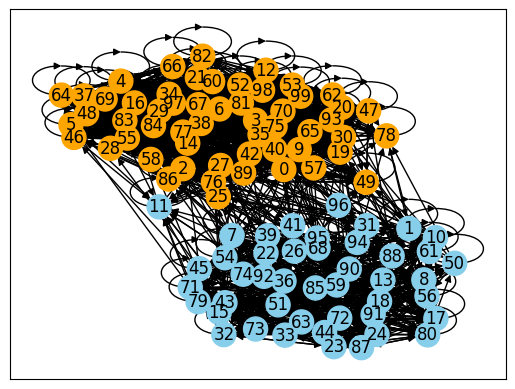

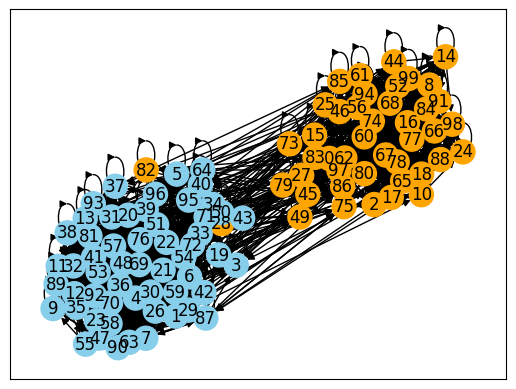

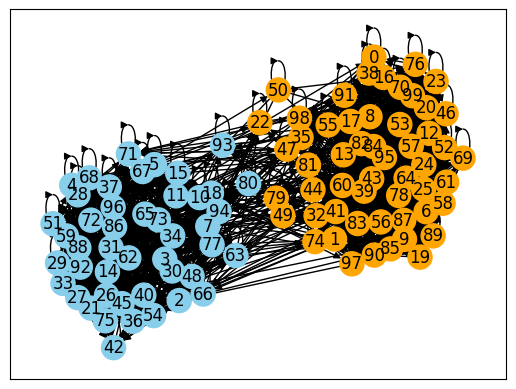

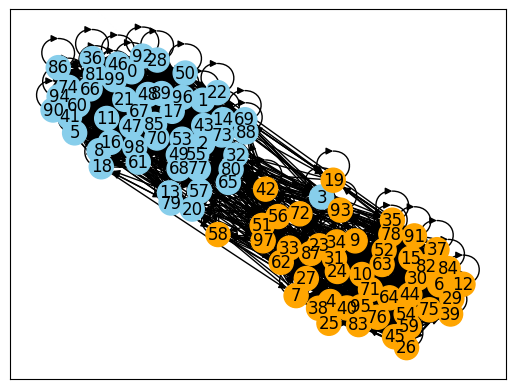

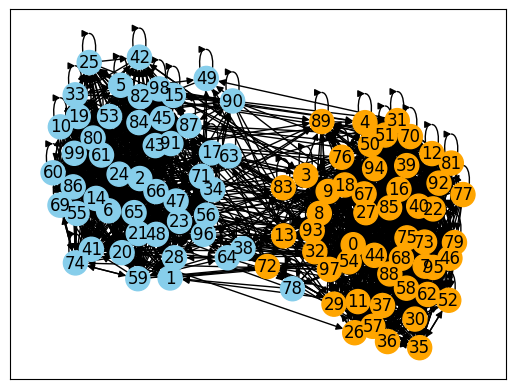

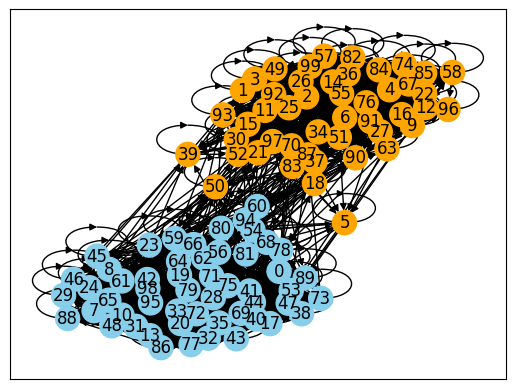

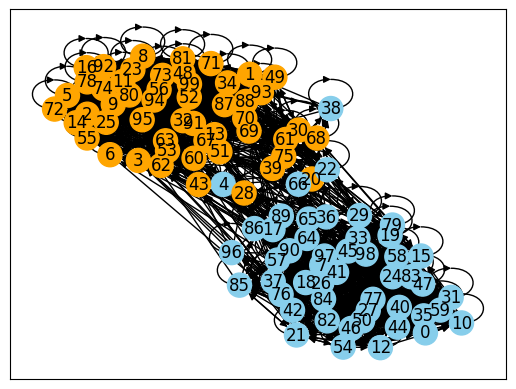

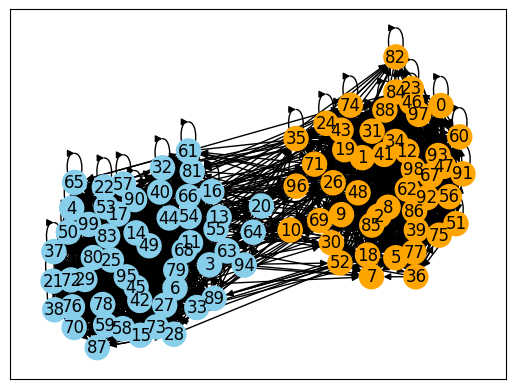

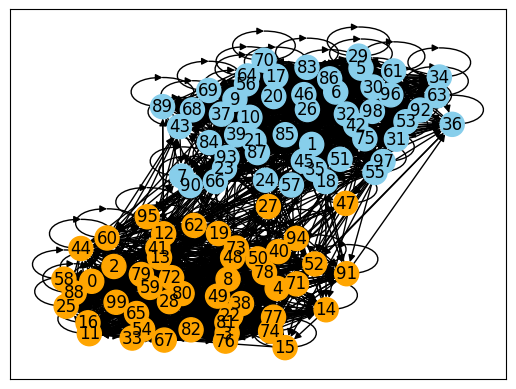

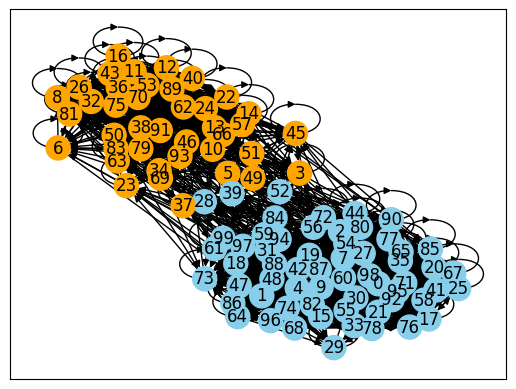

In [7]:
for G in dataset1:
    nxG = nx.from_numpy_array(G.a,create_using=nx.DiGraph)
    labels = np.argmax(G.y,axis=1)
    plot_graph_dir(nxG,labels)

In [13]:
class SyntheticDataset(Dataset):
    def __init__(self, graphs=None, **kwargs):
        self.graphs = graphs
        super().__init__(**kwargs)

    def read(self):
        return self.graphs

In [14]:
train_graphs, test_graphs = train_test_split(dataset1, test_size=0.2, random_state=42)
train_dataset = SyntheticDataset(train_graphs)
test_dataset = SyntheticDataset(test_graphs)

In [95]:
test_graphs

[Graph(n_nodes=100, n_node_features=2, n_edge_features=None, n_labels=2),
 Graph(n_nodes=100, n_node_features=2, n_edge_features=None, n_labels=2)]

In [7]:
train_dataset

SyntheticDataset(n_graphs=1)

In [15]:
from spektral.data import BatchLoader,DisjointLoader,SingleLoader
batch_size = 1

# Create data loaders for training and testing data
train_loader = BatchLoader(train_dataset, batch_size=batch_size)
test_loader = BatchLoader(test_dataset, batch_size=batch_size)

#train_loader = SingleLoader(train_dataset)
#test_loader = SingleLoader(test_dataset)


In [18]:
DATO=train_loader.__next__()

In [32]:
DATO[1].shape

(1, 100, 2)

In [15]:
n_classes=2
model = GCN(n_labels=n_classes,channels=16,l2_reg=1.0000,dropout_rate=0)



In [16]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.01), loss="binary_crossentropy", metrics=["accuracy"])


In [20]:
#from sklearn.tree import DecisionTreeClassifier
#decision_tree_model = DecisionTreeClassifier(criterion="entropy",random_state=0)
from sklearn.model_selection import cross_validate
resultado = cross_validate(model, train_loader, test_loader, cv=10)
print(resultado)


TypeError: Singleton array array(<spektral.data.loaders.BatchLoader object at 0x7f7873ddc9d0>,
      dtype=object) cannot be considered a valid collection.

In [18]:


# Define early stopping to prevent overfitting
es_callback = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    train_loader.load(),
    steps_per_epoch=train_loader.steps_per_epoch,
    epochs=100,
    validation_data=test_loader.load(),
    validation_steps=test_loader.steps_per_epoch#,
    #callbacks=[es_callback],
)


/usr/local/lib/python3.8/dist-packages/spektral/data/utils.py:221: UserWarning: you are shuffling a 'SyntheticDataset' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(a)


Epoch 1/100
8/8 [==============================] - 2s 39ms/step - loss: 4.1307 - accuracy: 0.9600 - val_loss: 3.3430 - val_accuracy: 0.9800
Epoch 2/100
8/8 [==============================] - 0s 10ms/step - loss: 2.8491 - accuracy: 0.9525 - val_loss: 2.2947 - val_accuracy: 0.9850
Epoch 3/100
8/8 [==============================] - 0s 9ms/step - loss: 1.9570 - accuracy: 0.9675 - val_loss: 1.5942 - val_accuracy: 0.9800
Epoch 4/100
8/8 [==============================] - 0s 9ms/step - loss: 1.3763 - accuracy: 0.9750 - val_loss: 1.1559 - val_accuracy: 0.9750
Epoch 5/100
8/8 [==============================] - 0s 10ms/step - loss: 1.0218 - accuracy: 0.9762 - val_loss: 0.8932 - val_accuracy: 0.9800
Epoch 6/100
8/8 [==============================] - 0s 9ms/step - loss: 0.8137 - accuracy: 0.9712 - val_loss: 0.7591 - val_accuracy: 0.9800
Epoch 7/100
8/8 [==============================] - 0s 10ms/step - loss: 0.6951 - accuracy: 0.9663 - val_loss: 0.6556 - val_accuracy: 0.9800
Epoch 8/100
8/8 [======

In [19]:
import pandas as pd
res=pd.DataFrame(history.history)

# Add row index as a new column
res.reset_index(inplace=True)

# Rename the new column to 'row_id'
res.rename(columns={'index': 'epoch'}, inplace=True)
res

,epoch,loss,accuracy,val_loss,val_accuracy
0,0,4.130743,0.96000,3.343044,0.980
1,1,2.849053,0.95250,2.294667,0.985
2,2,1.957010,0.96750,1.594180,0.980
3,3,1.376322,0.97500,1.155947,0.975
4,4,1.021774,0.97625,0.893227,0.980
...,...,...,...,...,...
95,95,0.195835,0.97125,0.201637,0.970
96,96,0.192015,0.97625,0.204987,0.980
97,97,0.190872,0.97250,0.195659,0.980
98,98,0.189435,0.97625,0.205925,0.975


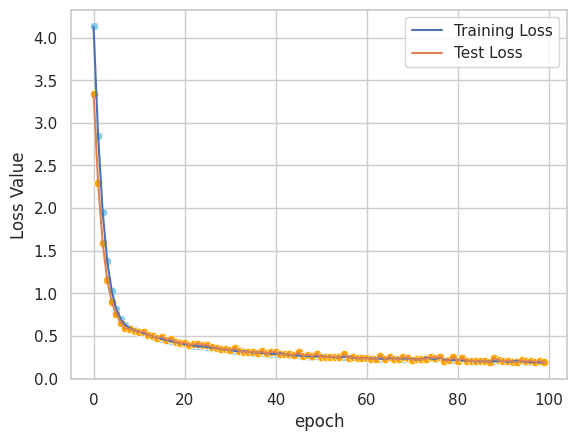

In [20]:
history.history['accuracy']

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
line1 = sns.lineplot(x="epoch", y='loss', data=res, label='Training Loss')
line2 = sns.lineplot(x="epoch", y='val_loss', data=res, label='Test Loss')


# Add points to each observation
scatter1 = sns.scatterplot(x="epoch", y='loss', data=res, marker='o', color='skyblue')
scatter2 = sns.scatterplot(x="epoch", y='val_loss', data=res, marker='o', color='orange')

# Change the y-axis label
plt.ylabel("Loss Value")

# Create a legend for the lines
plt.legend()

# Show the plot
plt.show()



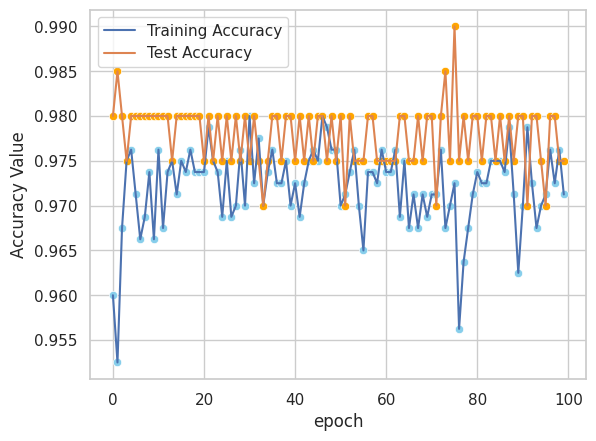

In [21]:
sns.set_theme(style="whitegrid")
line1 = sns.lineplot(x="epoch", y="accuracy", data=res, label='Training Accuracy')
line2 = sns.lineplot(x="epoch", y="val_accuracy", data=res, label='Test Accuracy')

# Add points to each observation
scatter1 = sns.scatterplot(x="epoch", y="accuracy", data=res, marker='o', color='skyblue')
scatter2 = sns.scatterplot(x="epoch", y="val_accuracy", data=res, marker='o', color='orange')

# Change the y-axis label
plt.ylabel("Accuracy Value")

# Create a legend for the lines
plt.legend()

# Show the plot
plt.show()

In [24]:
# PREDICCION


from sklearn.metrics import confusion_matrix,roc_auc_score,accuracy_score
for _ in range(test_loader.steps_per_epoch):
    inputs,target = test_loader.__next__()
    y_prediction = model(inputs, training=False)
    y_prediction = np.argmax(np.vstack(y_prediction), axis = 1)
    y_test=np.argmax(np.vstack(target), axis=1)
    #Create confusion matrix and normalizes it over predicted (columns)
    result = tf.math.confusion_matrix(y_test, y_prediction, num_classes=2) 
    print(result)

    # confusion_matrix = [[TP, FN],
    #                     [FP, TN]]
    TP = result[0,0].numpy()
    FN = result[0,1].numpy()
    FP = result[1,0].numpy()
    TN = result[1,1].numpy()

    accuracy = (TP+TN)/(TP+FP+FN+TN)
    precision = TP/(TP+FP)
    recall = TP/(TP+FN)
    especificity = TN/(TN+FP)
    f1 = (2*precision*recall)/(precision+recall)
    auc_score = roc_auc_score(y_test, y_prediction)

    print("accuracy (exactitud) = ", accuracy) # cantidad de predicciones positivas que fueron correctas
    print("precision = ", precision) # proporcion de casos positivos detectados
    print("recall = ", recall) # casos positivos que fueron correctamente identificadas por el algoritmo
    print("especificity = ", especificity) # casos negativos que el algoritmo ha clasificado correctamente
    print("f1 = ", f1)
    print("auc_score = ", auc_score)
    print("==============================")

tf.Tensor(
[[47  2]
 [ 1 50]], shape=(2, 2), dtype=int32)
accuracy (exactitud) =  0.97
precision =  0.9791666666666666
recall =  0.9591836734693877
especificity =  0.9803921568627451
f1 =  0.9690721649484536
auc_score =  0.9697879151660664
tf.Tensor(
[[42  2]
 [ 0 56]], shape=(2, 2), dtype=int32)
accuracy (exactitud) =  0.98
precision =  1.0
recall =  0.9545454545454546
especificity =  1.0
f1 =  0.9767441860465117
auc_score =  0.9772727272727273


In [25]:
for _ in range(test_loader.steps_per_epoch):
    inputs,target = test_loader.__next__()
    y_prediction = model(inputs, training=False)
    y_prediction = np.argmax(np.vstack(y_prediction), axis = 1)
    y_test=np.argmax(np.vstack(target), axis=1)
    #Create confusion matrix and normalizes it over predicted (columns)
    #result = tf.math.confusion_matrix(y_test, y_prediction, num_classes=2) 
    #print(result)
    conf_mat = confusion_matrix(y_prediction, y_test)
    print(conf_mat)

[[47  1]
 [ 2 50]]
[[42  0]
 [ 2 56]]


/usr/local/lib/python3.8/dist-packages/spektral/data/utils.py:221: UserWarning: you are shuffling a 'SyntheticDataset' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(a)


In [157]:
y_prediction

array([[81, 29]])

In [141]:
predictions = []
targets = []
step = 0
while step < test_loader.steps_per_epoch:
        step += 1
        inputs, target = test_loader.__next__()
        pred = model(inputs, training=False)
        predictions.append(pred)
        targets.append(target)
    
predictions = np.vstack(predictions)
    
targets = np.vstack(targets)
# Post-process the predictions if necessary (e.g., convert probabilities to class labels)
predicted_values = np.argmax(np.squeeze(predictions), axis=1)
true_labels = np.argmax(np.squeeze(targets),axis =1 )

/usr/local/lib/python3.8/dist-packages/spektral/data/utils.py:221: UserWarning: you are shuffling a 'SyntheticDataset' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(a)


In [153]:
np.vstack(pred)

array([[9.9558842e-01, 4.4115223e-03],
       [2.4771646e-03, 9.9752277e-01],
       [9.9926430e-01, 7.3574361e-04],
       [1.6176382e-02, 9.8382366e-01],
       [1.3805388e-03, 9.9861944e-01],
       [1.6808737e-02, 9.8319131e-01],
       [6.8429448e-03, 9.9315709e-01],
       [1.3229217e-03, 9.9867707e-01],
       [9.9979550e-01, 2.0451471e-04],
       [6.3764263e-04, 9.9936241e-01],
       [9.9983633e-01, 1.6369307e-04],
       [6.6256669e-04, 9.9933738e-01],
       [9.4258145e-04, 9.9905747e-01],
       [9.2970824e-04, 9.9907035e-01],
       [9.9988127e-01, 1.1869829e-04],
       [9.9556267e-01, 4.4373367e-03],
       [9.9971300e-01, 2.8700262e-04],
       [9.9951029e-01, 4.8970769e-04],
       [9.9977297e-01, 2.2699077e-04],
       [5.7246026e-02, 9.4275397e-01],
       [1.3004267e-03, 9.9869955e-01],
       [2.5828322e-03, 9.9741721e-01],
       [6.2023061e-03, 9.9379772e-01],
       [7.6707383e-04, 9.9923289e-01],
       [9.9988055e-01, 1.1938754e-04],
       [9.9930561e-01, 6.

In [147]:
np.argmax(np.squeeze(predictions), axis=1)

array([[81, 29],
       [14, 32]])

In [151]:
np.squeeze(predictions)

array([[[9.9795747e-01, 2.0424866e-03],
        [9.8730614e-03, 9.9012697e-01],
        [9.9691856e-01, 3.0814370e-03],
        [9.9870014e-01, 1.2998310e-03],
        [9.9769598e-01, 2.3040334e-03],
        [2.1070414e-03, 9.9789304e-01],
        [2.1250097e-03, 9.9787498e-01],
        [9.4770111e-02, 9.0522993e-01],
        [9.9712652e-01, 2.8735432e-03],
        [4.0563331e-03, 9.9594361e-01],
        [5.7918713e-03, 9.9420810e-01],
        [9.9889141e-01, 1.1086140e-03],
        [9.6499580e-01, 3.5004187e-02],
        [9.9719560e-01, 2.8044349e-03],
        [9.9805719e-01, 1.9428320e-03],
        [9.9884546e-01, 1.1545011e-03],
        [9.9851424e-01, 1.4857046e-03],
        [2.5541564e-03, 9.9744582e-01],
        [7.3182523e-02, 9.2681742e-01],
        [9.8731691e-01, 1.2683024e-02],
        [2.5020181e-03, 9.9749798e-01],
        [7.9148673e-03, 9.9208516e-01],
        [9.9883205e-01, 1.1680152e-03],
        [4.5681074e-02, 9.5431888e-01],
        [6.0986429e-02, 9.3901354e-01],


In [119]:
inputs, target = test_loader.__next__()

/usr/local/lib/python3.8/dist-packages/spektral/data/utils.py:221: UserWarning: you are shuffling a 'SyntheticDataset' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(a)


In [123]:
pred = model(inputs, training=False)
pred

<tf.Tensor: shape=(1, 100, 2), dtype=float32, numpy=
array([[[9.9558842e-01, 4.4115223e-03],
        [2.4771646e-03, 9.9752277e-01],
        [9.9926430e-01, 7.3574361e-04],
        [1.6176382e-02, 9.8382366e-01],
        [1.3805388e-03, 9.9861944e-01],
        [1.6808737e-02, 9.8319131e-01],
        [6.8429448e-03, 9.9315709e-01],
        [1.3229217e-03, 9.9867707e-01],
        [9.9979550e-01, 2.0451471e-04],
        [6.3764263e-04, 9.9936241e-01],
        [9.9983633e-01, 1.6369307e-04],
        [6.6256669e-04, 9.9933738e-01],
        [9.4258145e-04, 9.9905747e-01],
        [9.2970824e-04, 9.9907035e-01],
        [9.9988127e-01, 1.1869829e-04],
        [9.9556267e-01, 4.4373367e-03],
        [9.9971300e-01, 2.8700262e-04],
        [9.9951029e-01, 4.8970769e-04],
        [9.9977297e-01, 2.2699077e-04],
        [5.7246026e-02, 9.4275397e-01],
        [1.3004267e-03, 9.9869955e-01],
        [2.5828322e-03, 9.9741721e-01],
        [6.2023061e-03, 9.9379772e-01],
        [7.6707383e-04, 9.9

In [125]:
predictions = []
predictions.append(pred)
predictions = np.vstack(predictions)
predictions

array([[[9.9558842e-01, 4.4115223e-03],
        [2.4771646e-03, 9.9752277e-01],
        [9.9926430e-01, 7.3574361e-04],
        [1.6176382e-02, 9.8382366e-01],
        [1.3805388e-03, 9.9861944e-01],
        [1.6808737e-02, 9.8319131e-01],
        [6.8429448e-03, 9.9315709e-01],
        [1.3229217e-03, 9.9867707e-01],
        [9.9979550e-01, 2.0451471e-04],
        [6.3764263e-04, 9.9936241e-01],
        [9.9983633e-01, 1.6369307e-04],
        [6.6256669e-04, 9.9933738e-01],
        [9.4258145e-04, 9.9905747e-01],
        [9.2970824e-04, 9.9907035e-01],
        [9.9988127e-01, 1.1869829e-04],
        [9.9556267e-01, 4.4373367e-03],
        [9.9971300e-01, 2.8700262e-04],
        [9.9951029e-01, 4.8970769e-04],
        [9.9977297e-01, 2.2699077e-04],
        [5.7246026e-02, 9.4275397e-01],
        [1.3004267e-03, 9.9869955e-01],
        [2.5828322e-03, 9.9741721e-01],
        [6.2023061e-03, 9.9379772e-01],
        [7.6707383e-04, 9.9923289e-01],
        [9.9988055e-01, 1.1938754e-04],


In [149]:
#predicted_values = 
np.argmax(np.squeeze(pred), axis=1)

array([0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0])

In [140]:
np.argmax(np.squeeze(target),axis =1)

array([0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0])

In [142]:
from sklearn.metrics import confusion_matrix,roc_auc_score,accuracy_score
conf_mat = confusion_matrix(predicted_values, true_labels)
print(conf_mat)


ValueError: Classification metrics can't handle a mix of multiclass-multioutput and multilabel-indicator targets

In [110]:
auc_score = roc_auc_score(true_labels, predicted_values)
accuracy_score = accuracy_score(true_labels, predicted_values)

print("AUC Score:", auc_score)
print("Accuracy Score:", accuracy_score)

ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.